In [1]:
# Q10 

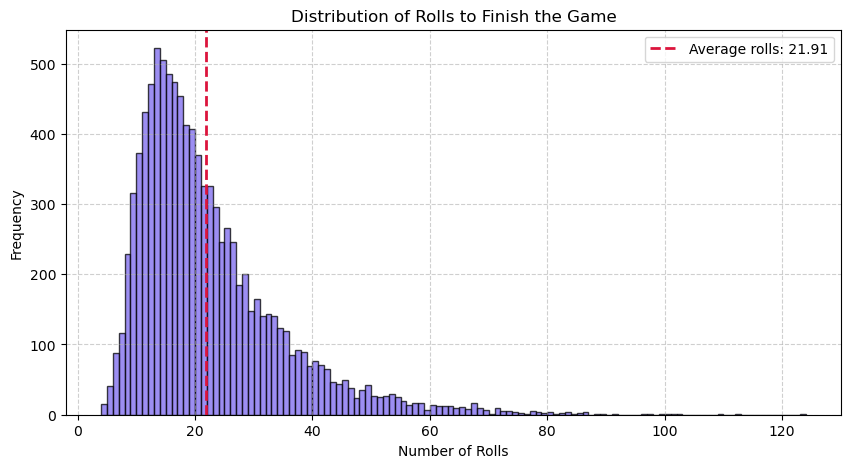

Simulated 10000 games
Average number of rolls to finish the game: 21.91
Probability of finishing within 25 rolls: 0.7169


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Define ladders and snakes positions (start:end)
ladder_positions = {5: 14, 10: 28, 32: 45}
snake_positions = {15: 7, 37: 19, 49: 34}

def play_single_game():
    current_position = 1
    dice_rolls = 0

    while current_position < 50:
        dice_roll = random.randint(1, 6)
        dice_rolls += 1

        if current_position + dice_roll <= 50:
            current_position += dice_roll

            if current_position in ladder_positions:
                current_position = ladder_positions[current_position]
            elif current_position in snake_positions:
                current_position = snake_positions[current_position]
    return dice_rolls

def run_simulations(total_games=10000):
    rolls_per_game = [play_single_game() for _ in range(total_games)]

    average_rolls = np.mean(rolls_per_game)
    probability_finish_25_or_less = np.mean(np.array(rolls_per_game) <= 25)

    # Plot histogram
    plt.figure(figsize=(10,5))
    plt.hist(rolls_per_game, bins=range(min(rolls_per_game), max(rolls_per_game)+1), 
             color='mediumslateblue', edgecolor='black', alpha=0.75)
    plt.axvline(average_rolls, color='crimson', linestyle='dashed', linewidth=2, 
                label=f'Average rolls: {average_rolls:.2f}')
    plt.title('Distribution of Rolls to Finish the Game')
    plt.xlabel('Number of Rolls')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return average_rolls, probability_finish_25_or_less

if __name__ == "__main__":
    total_games = 10000
    avg_rolls, prob_25_or_less = run_simulations(total_games)

    print(f"Simulated {total_games} games")
    print(f"Average number of rolls to finish the game: {avg_rolls:.2f}")
    print(f"Probability of finishing within 25 rolls: {prob_25_or_less:.4f}")
